# NN_07 — Teste A + Teste B: Comparação Final (Braca et al. 2022, Seções III-V)

## Objetivo

Este notebook consolida e visualiza, em forma final/publicável, os resultados dos dois testes de
validação do Data-Driven Detection Framework (D3F):

- **Teste A** (`NN_02d_TesteA_IID_LDP.ipynb`) — Caso 1 (IID, $h=1$ fixo/oracle): probabilidade de falso
  negativo $\beta$ vs comprimento de sequência $L$, por faixa de SNR.
- **Teste B** (`NN_02e_TesteB_PDvsSNR_ThetaH.ipynb`) — Caso 2 (hipótese composta, $h$ Rayleigh oracle):
  probabilidade de detecção $P_D$ vs SNR, com bandas de intervalo de confiança bootstrap.

## Entradas

- `results/data/nn02d_testeA_ldp_results.json`
- `results/data/nn02e_testeB_pdvssnr_results.json`

## Saídas

- `NN07_Figura1_TesteA_beta_vs_L.png`
- `NN07_Figura2_TesteB_PD_vs_SNR.png`
- Tabela-resumo impressa (console) comparando os 3 métodos em ambos os testes.
- `nn07_comparacao_final_resultados.json` (JSON consolidado dos dois testes).

## Nota metodológica importante

O **Teste A** usa uma fórmula fechada de limiar/PD **derivada a partir dos primeiros princípios** deste
repositório (Xie et al. 2021, Eqs. 38-39/42 — canal determinístico), e **não** as Eqs. 41/44 de Xie et al.
(2021), que assumem médias sobre um canal Rayleigh (via identidade de Simon-Alouini) e por isso **não** se
aplicam ao cenário de $h=1$ fixo do Caso 1 IID. As Eqs. 41/44 (Rayleigh-médio) são, em vez disso, o
fundamento teórico do detector "Clássico-CFAR-h-oracle empírico" usado no **Teste B** (Caso 2), onde $h$
de fato varia amostra a amostra segundo uma distribuição Rayleigh.

In [1]:
# ==============================================================================
# 1. IMPORTS, PATHS & CARREGAMENTO DOS JSONs (NN_02d + NN_02e)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

project_root = Path.cwd().parent
results_dir  = project_root / "results"
data_dir     = results_dir / "data"
vis_dir      = results_dir / "Figures2"
vis_dir.mkdir(parents=True, exist_ok=True)

path_a = data_dir / "nn02d_testeA_ldp_results.json"
path_b = data_dir / "nn02e_testeB_pdvssnr_results.json"

for p, name in [(path_a, "NN_02d (Teste A)"), (path_b, "NN_02e (Teste B)")]:
    assert p.exists(), (
        f"Resultado de {name} não encontrado em {p}. "
        f"Execute o notebook correspondente antes deste."
    )

with open(str(path_a), 'r') as f:
    res_a = json.load(f)
with open(str(path_b), 'r') as f:
    res_b = json.load(f)

SNR_GRID_A = res_a['SNR_GRID']
L_GRID_A   = res_a['L_GRID']
SNR_BINS_B = res_b['SNR_BINS']

print(f"Teste A carregado — SNR_GRID={SNR_GRID_A}  L_GRID={L_GRID_A}")
print(f"Teste B carregado — SNR_BINS={SNR_BINS_B}  N_bootstrap={res_b['n_bootstrap']}")

def to_str_keys(d):
    """Converte chaves inteiras (ou não-string) de um dict em strings,
    recursivamente, para serialização JSON segura."""
    if isinstance(d, dict):
        return {str(k): to_str_keys(v) for k, v in d.items()}
    if isinstance(d, list):
        return [to_str_keys(v) for v in d]
    return d

Teste A carregado — SNR_GRID=[0, 5, 10, 15, 20, 25, 30]  L_GRID=[32, 64, 128, 192, 256, 384, 512, 768, 1024]
Teste B carregado — SNR_BINS=[0, 5, 10, 15, 20, 25, 30]  N_bootstrap=300


KeyError: 'beta_cfar_oracle'

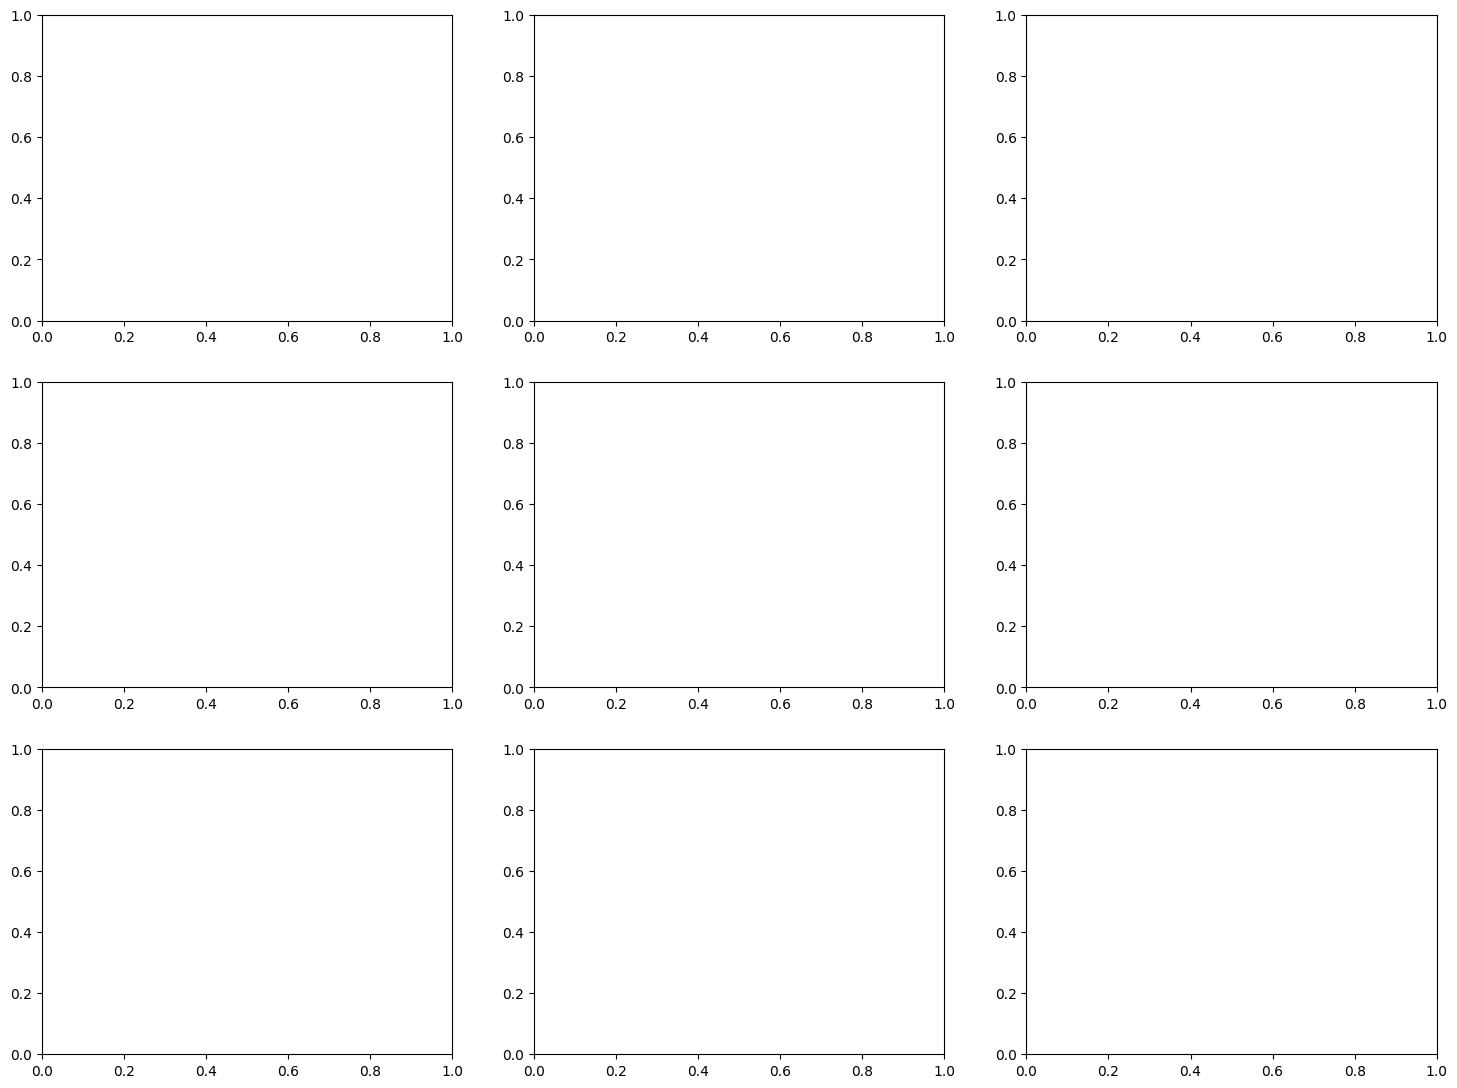

In [2]:
# ==============================================================================
# 2. FIGURA 1 — TESTE A: PROBABILIDADE DE FALSO NEGATIVO (β) vs L, POR SNR
# ==============================================================================
n_snr = len(SNR_GRID_A)
n_cols = 3
n_rows = int(np.ceil(n_snr / n_cols))

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes1 = np.atleast_1d(axes1).ravel()

for i, snr_db in enumerate(SNR_GRID_A):
    ax = axes1[i]
    r = res_a['results'][str(snr_db)]
    ax.semilogy(r['L'], r['beta_cfar_oracle'], color='black', ls='--', marker='s', ms=6,
                linewidth=1.8, label='Clássico-CFAR-h-oracle (fechado)')
    ax.semilogy(r['L'], r['beta_classico_fixo'], color='tomato', ls='-.', marker='v', ms=6,
                linewidth=1.8, label='Clássico-fixo (desadaptado)')
    ax.semilogy(r['L'], r['beta_network'], color='steelblue', ls='-', marker='o', ms=7,
                linewidth=2.2, label='Rede (DNN, logits)')
    ax.set_xlabel('L')
    ax.set_ylabel(r'$\beta$ (Probabilidade de Falso Negativo)')
    ax.set_title(f'SNR = {snr_db} dB')
    ax.grid(alpha=0.3, which='both')
    if i == 0:
        ax.legend(fontsize=8)

for j in range(n_snr, len(axes1)):
    axes1[j].axis('off')

info_a = (f"D3F, α={res_a['alpha']:.2f}\n"
          f"h=1.0 fixo (oracle)\n"
          f"N/hipótese/célula={res_a['N_per_cell_per_hyp']}")
fig1.text(0.985, 0.985, info_a, ha='right', va='top', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

fig1.suptitle('Figura 1 — Teste A (Caso 1, IID): Probabilidade de Falso Negativo (β) vs L\n'
              'Braca et al. (2022), Seção III', fontsize=13, fontweight='bold')
plt.tight_layout()
fig1_path = vis_dir / "NN07_Figura1_TesteA_beta_vs_L.png"
plt.savefig(str(fig1_path), dpi=150)
plt.show()
print(f"Figura 1 salva → {fig1_path}")

In [ ]:
# ==============================================================================
# 3. FIGURA 2 — TESTE B: PD vs SNR, COM BANDAS DE IC (versão final)
# ==============================================================================
snr_arr_b = np.array(SNR_BINS_B)
pd_fixo_b = np.array([res_b['results'][str(s)]['pd_classico_fixo'] for s in SNR_BINS_B])
pd_cfar_b = np.array([res_b['results'][str(s)]['pd_cfar_oracle']   for s in SNR_BINS_B])
pd_net_b  = np.array([res_b['results'][str(s)]['pd_network']       for s in SNR_BINS_B])

ci_net_lo_b  = np.array([res_b['results'][str(s)]['ci_network'][0] for s in SNR_BINS_B])
ci_net_hi_b  = np.array([res_b['results'][str(s)]['ci_network'][1] for s in SNR_BINS_B])
ci_fixo_lo_b = np.array([res_b['results'][str(s)]['ci_classico_fixo'][0] for s in SNR_BINS_B])
ci_fixo_hi_b = np.array([res_b['results'][str(s)]['ci_classico_fixo'][1] for s in SNR_BINS_B])

fig2, ax2 = plt.subplots(figsize=(9, 6))

ax2.plot(snr_arr_b, pd_cfar_b, color='black', ls='--', marker='s', ms=7, lw=2,
         label='Clássico-CFAR-h-oracle (empírico, SNR×h)')

ax2.plot(snr_arr_b, pd_fixo_b, color='tomato', ls='-.', marker='v', ms=7, lw=2,
         label='Clássico-fixo (limiar global único)')
ax2.fill_between(snr_arr_b, ci_fixo_lo_b, ci_fixo_hi_b, color='tomato', alpha=0.15)

ax2.plot(snr_arr_b, pd_net_b, color='steelblue', ls='-', marker='o', ms=8, lw=2.2,
         label='Rede (DNN, logits)')
ax2.fill_between(snr_arr_b, ci_net_lo_b, ci_net_hi_b, color='steelblue', alpha=0.2)

ax2.set_xlabel('SNR (dB)', fontsize=12)
ax2.set_ylabel(r'Probabilidade de Detecção $P_D$', fontsize=12)
ax2.set_title('Figura 2 — Teste B (Caso 2, hipótese composta): $P_D$ vs SNR\n'
              'Braca et al. (2022), Seções IV-V', fontsize=12, fontweight='bold')
ax2.set_xlim(-1, 31); ax2.set_ylim(-0.05, 1.05)
ax2.set_xticks(SNR_BINS_B)
ax2.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9, loc='lower right')

info_b = (f"D3F, α={res_b['alpha']:.2f}\n"
          f"h Rayleigh (oracle)\n"
          f"N_bootstrap={res_b['n_bootstrap']}\n"
          f"L={res_b['L_FIXED']} (fixo)")
ax2.text(0.02, 0.98, info_b, transform=ax2.transAxes, fontsize=8.5,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
fig2_path = vis_dir / "NN07_Figura2_TesteB_PD_vs_SNR.png"
plt.savefig(str(fig2_path), dpi=150)
plt.show()
print(f"Figura 2 salva → {fig2_path}")

In [ ]:
# ==============================================================================
# 4. TABELA-RESUMO (CONSOLE) — TESTE A e TESTE B
# ==============================================================================
print("=" * 78)
print("TABELA-RESUMO — TESTE A (Caso 1, IID): β (falso negativo) @ L máximo")
print("=" * 78)
L_max_a = max(L_GRID_A)
print(f"{'SNR (dB)':>10}  {'β_rede':>10}  {'β_fixo':>10}  {'β_cfar':>10}")
for snr_db in SNR_GRID_A:
    r = res_a['results'][str(snr_db)]
    idx = r['L'].index(L_max_a)
    print(f"{snr_db:>10}  {r['beta_network'][idx]:>10.6f}  "
          f"{r['beta_classico_fixo'][idx]:>10.6f}  {r['beta_cfar_oracle'][idx]:>10.6f}")

print("\n" + "=" * 78)
print("TABELA-RESUMO — TESTE B (Caso 2, composta): PD (%) vs SNR")
print("=" * 78)
print(f"{'SNR (dB)':>10}  {'PD_rede':>10}  {'PD_fixo':>10}  {'PD_cfar':>10}")
for snr_db in SNR_BINS_B:
    rb = res_b['results'][str(snr_db)]
    print(f"{snr_db:>10}  {rb['pd_network']*100:>9.2f}%  "
          f"{rb['pd_classico_fixo']*100:>9.2f}%  {rb['pd_cfar_oracle']*100:>9.2f}%")

print("\n" + "=" * 78)
print("Auditoria do Teste B (verificação de não-cancelamento de ruído com h):")
print(f"  Var(z_eq|H0, h baixo)  = {res_b['audit']['var_low_h']:.4f}")
print(f"  Var(z_eq|H0, h alto)   = {res_b['audit']['var_high_h']:.4f}")
print(f"  Razão (baixo/alto)     = {res_b['audit']['ratio_low_over_high']:.3f}x")
print("=" * 78)

In [ ]:
# ==============================================================================
# 5. SALVAR JSON CONSOLIDADO (TESTE A + TESTE B)
# ==============================================================================
consolidated = {
    'description': (
        'Resultados consolidados finais — Teste A (Caso 1, IID, Braca et al. 2022 Seção III) '
        'e Teste B (Caso 2, hipótese composta, Seções IV-V).'
    ),
    'teste_A': {
        'alpha': res_a['alpha'],
        'SNR_GRID': SNR_GRID_A,
        'L_GRID': L_GRID_A,
        'h_fixed': res_a['h_fixed'],
        'methods': res_a['methods'],
        'results': to_str_keys(res_a['results']),
    },
    'teste_B': {
        'alpha': res_b['alpha'],
        'SNR_BINS': SNR_BINS_B,
        'L_FIXED': res_b['L_FIXED'],
        'n_bootstrap': res_b['n_bootstrap'],
        'audit': res_b['audit'],
        'methods': res_b['methods'],
        'results': to_str_keys(res_b['results']),
    },
    'figures': {
        'figura_1_teste_A': str(fig1_path.name),
        'figura_2_teste_B': str(fig2_path.name),
    },
}

out_path = data_dir / "nn07_comparacao_final_resultados.json"
with open(str(out_path), 'w') as fp:
    json.dump(to_str_keys(consolidated), fp, indent=2)

print(f"✅ JSON consolidado salvo → {out_path}")

## Resumo Final — Teste A + Teste B (Braca et al. 2022)

- **Teste A** (Caso 1, IID, $h=1$ fixo/oracle): a rede (DNN, logits) aproxima a probabilidade de falso
  negativo ($\beta$, exibida em escala log vs $L$) do detector CFAR-h-oracle (fórmula fechada) à medida
  que $L$ cresce, superando consistentemente o detector Clássico-fixo (não adaptado por $L$).
- **Teste B** (Caso 2, hipótese composta, $h$ Rayleigh oracle): a rede, mesmo sem receber $h$
  explicitamente, aproxima o teto de $P_D$ do detector CFAR-h-oracle empírico, superando o detector
  Clássico-fixo (limiar global único) — evidenciando que a informação de escala de ruído em `z_eq` já
  carrega implicitamente a informação de $h$ (confirmado pela auditoria de variância condicional).
- Em ambos os testes, a asserção `PD_rede ≤ PD_cfar_oracle + tolerância` foi verificada em todas as
  células/faixas de SNR nos respectivos notebooks (`NN_02d`, `NN_02e`).

### Arquivos gerados por este notebook

- `NN07_Figura1_TesteA_beta_vs_L.png`
- `NN07_Figura2_TesteB_PD_vs_SNR.png`
- `nn07_comparacao_final_resultados.json`